In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

In [ ]:
"""Identify housing data (with at least 1000 distinct examples) that cannot come from
a preprocessed dataset. It must include at MINIMUM these following attributes: price, age, 
number of bed rooms, number of bathrooms, and square feet of the house. These features must go
through a model that uses the data to predict the selling price of properties in your selected
city in the United States. The project must be coded in Python and utilize Scikit-learn; all uopdates
must be pushed to Git, as that is where the majority of t."""

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [ ]:
from homeharvest import scrape_property
import pandas as pd

# Scrape 7000 datasets from Chicago sold within the past year using
# the homeharvest library. Accept extra property data to gain as many features as possible for
# a more accurate evaluation. The data is raw and original.
properties_df: pd.DataFrame = scrape_property(
    location="Chicago, IL",
    listing_type="sold",
    past_days=365,
    limit=7000,
    extra_property_data=True
)

properties_df.to_csv("listings.csv", index=False)


# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

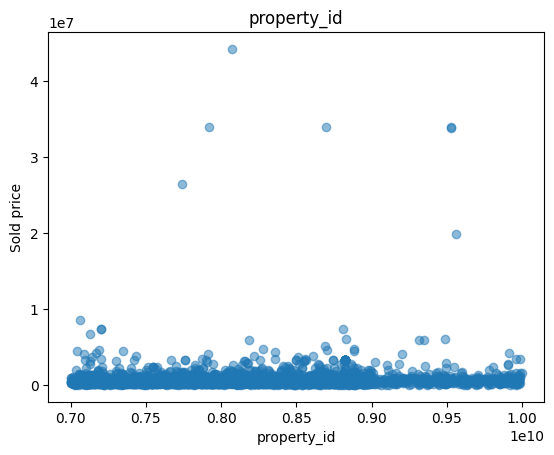

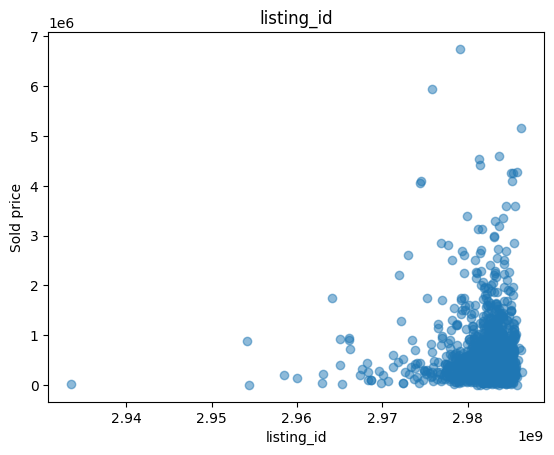

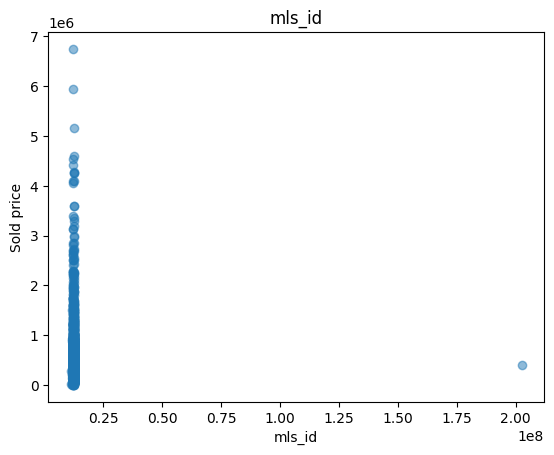

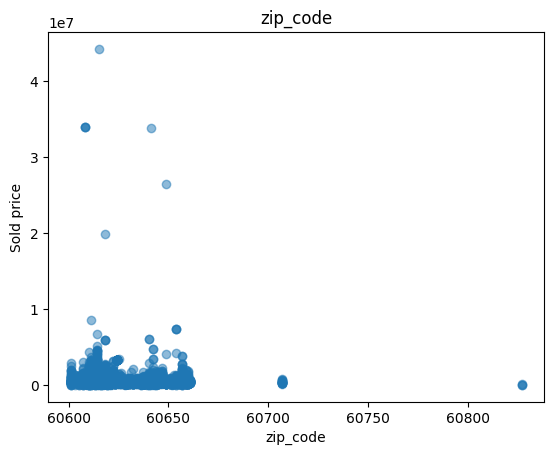

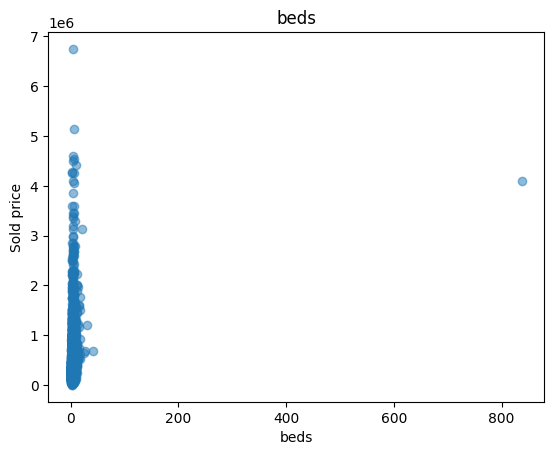

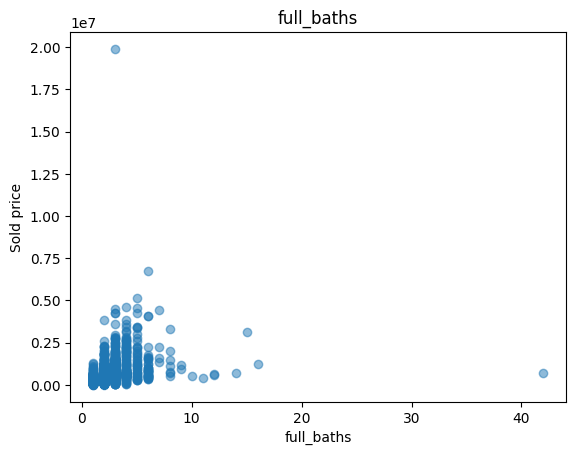

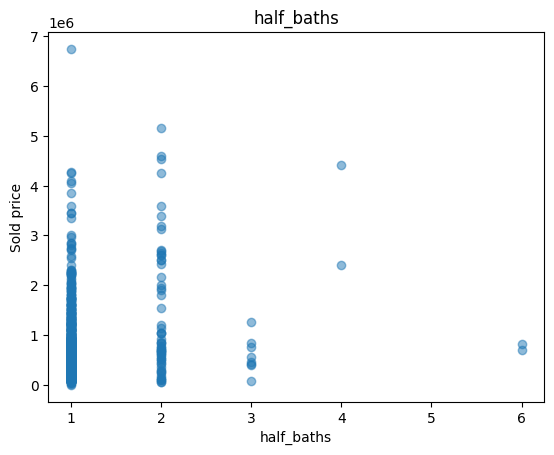

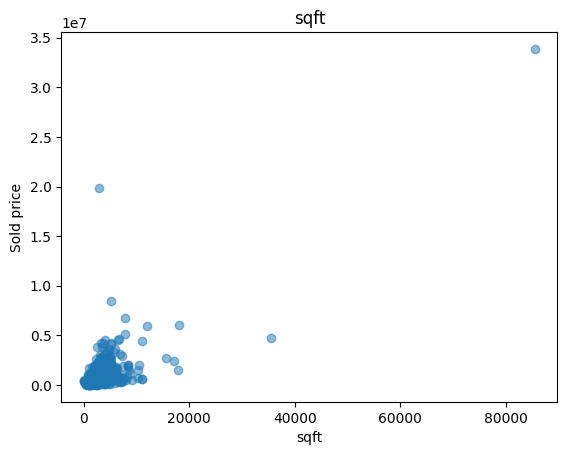

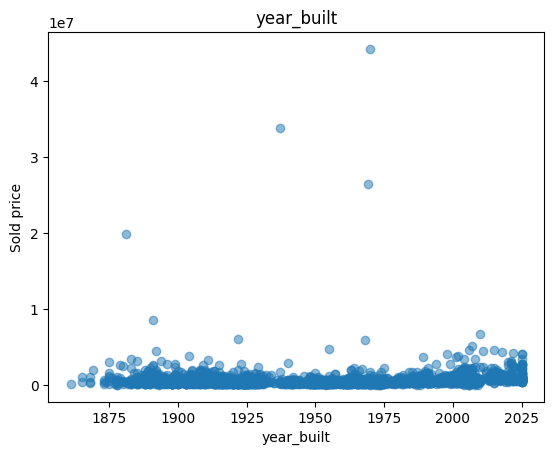

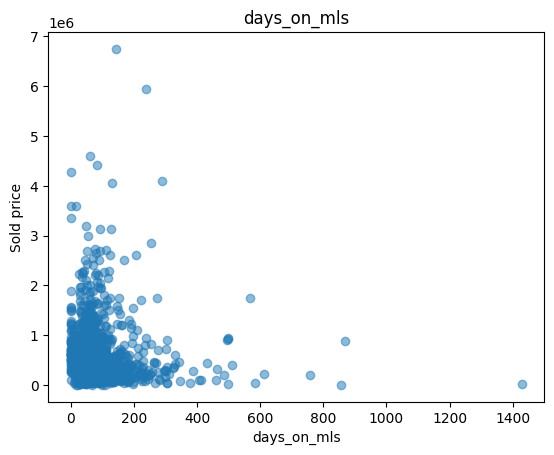

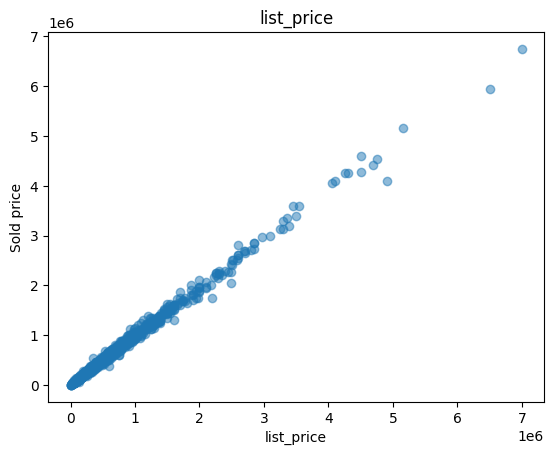

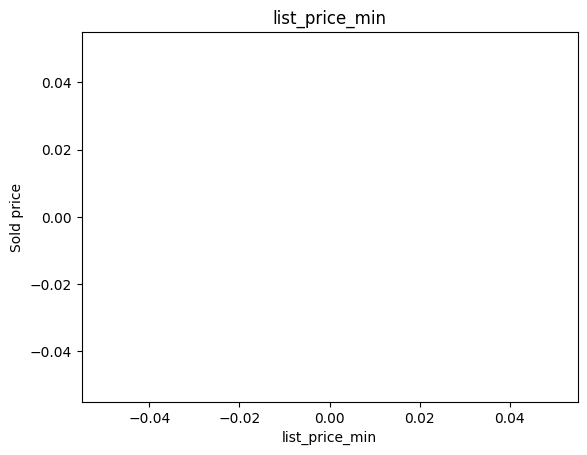

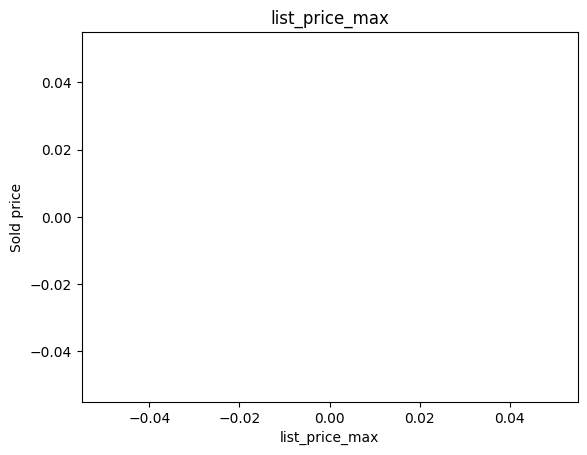

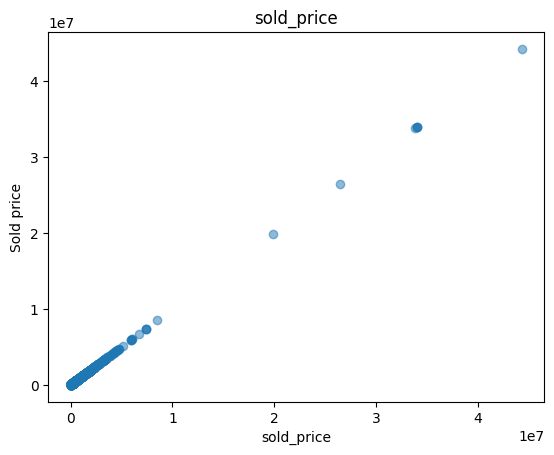

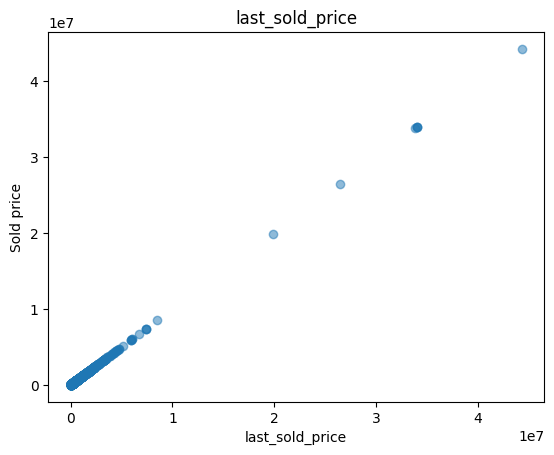

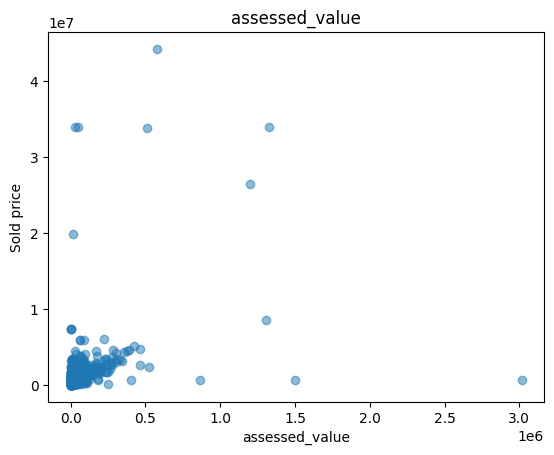

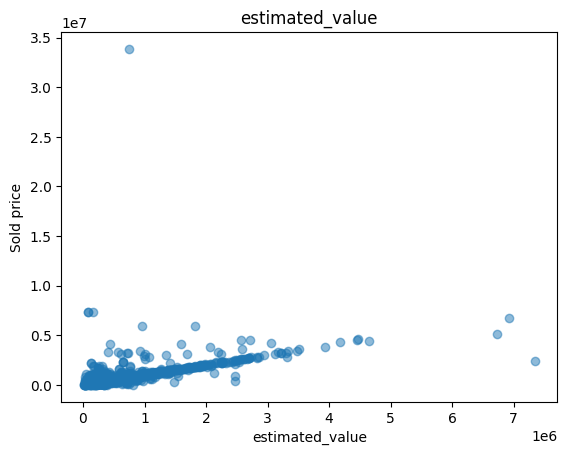

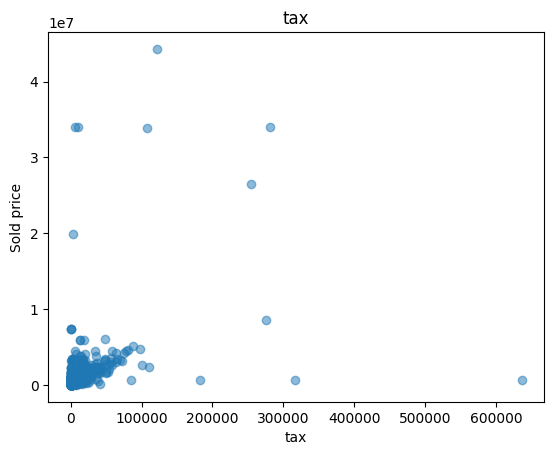

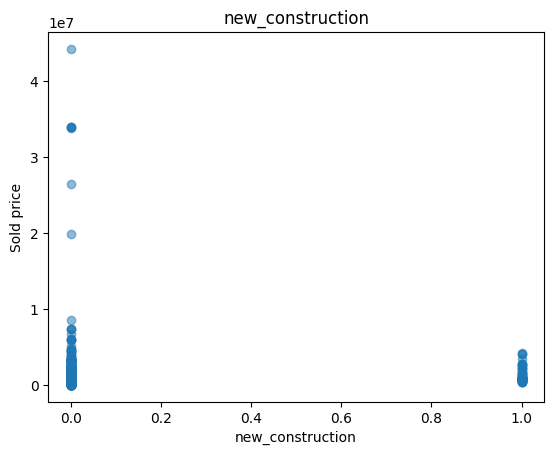

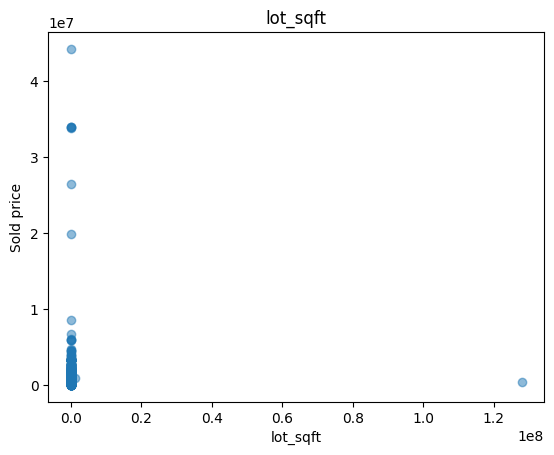

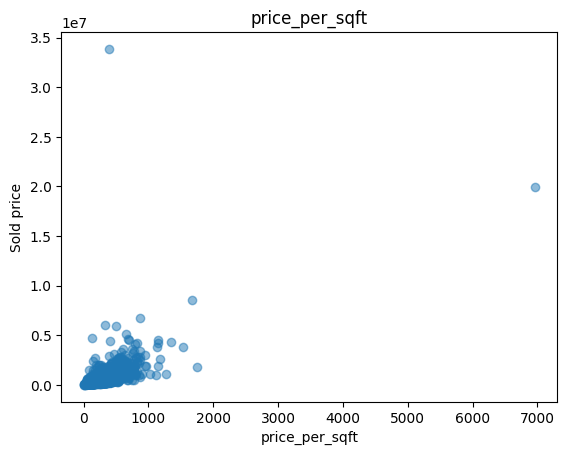

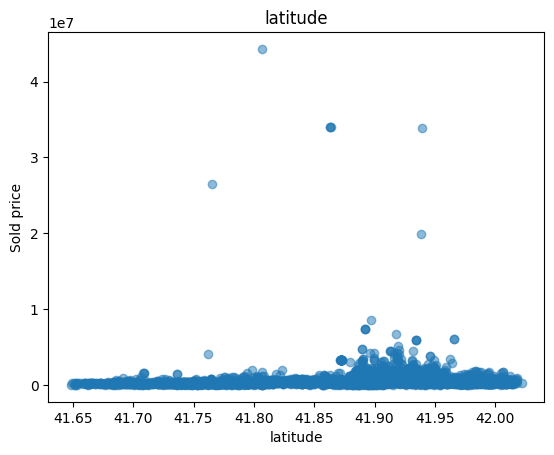

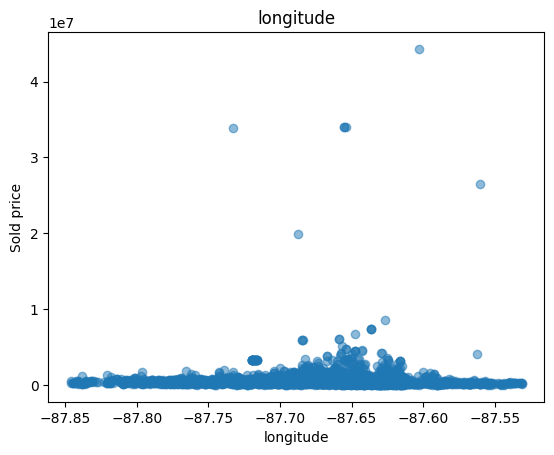

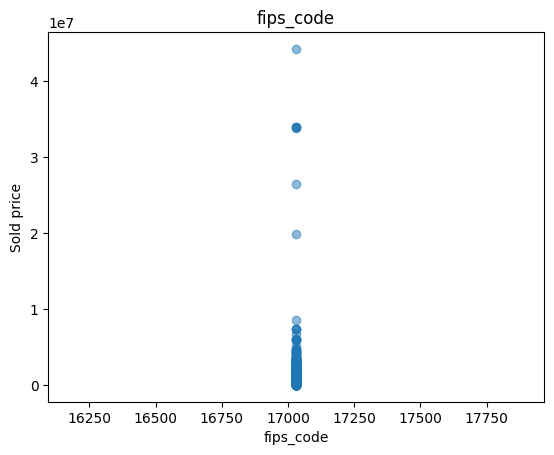

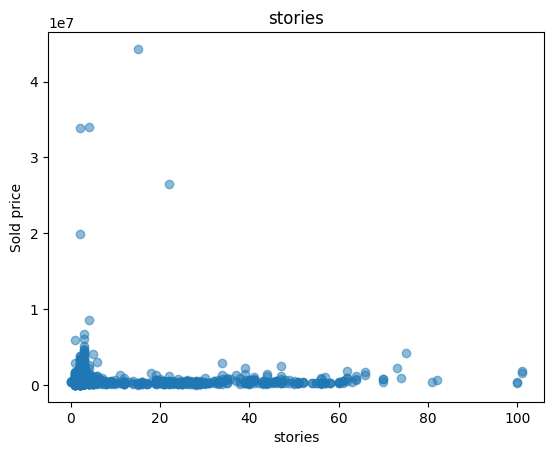

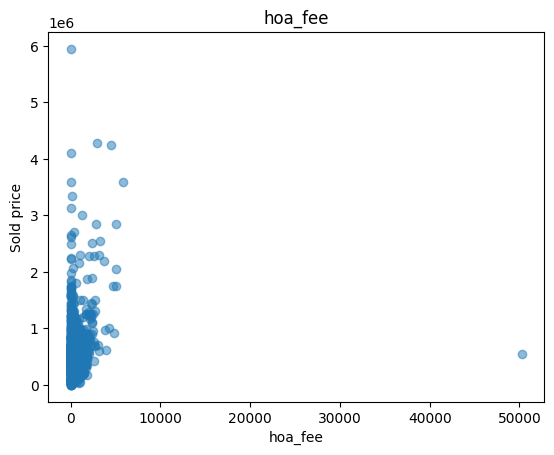

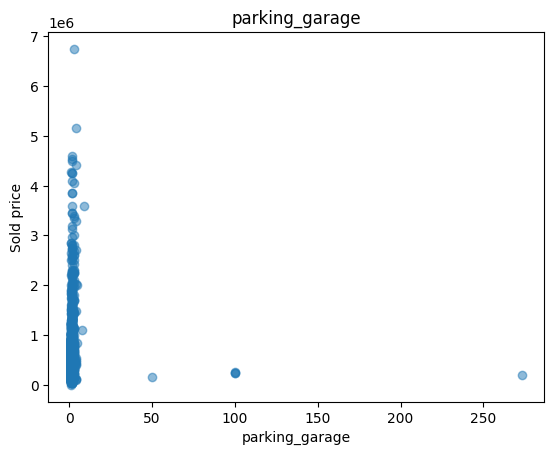

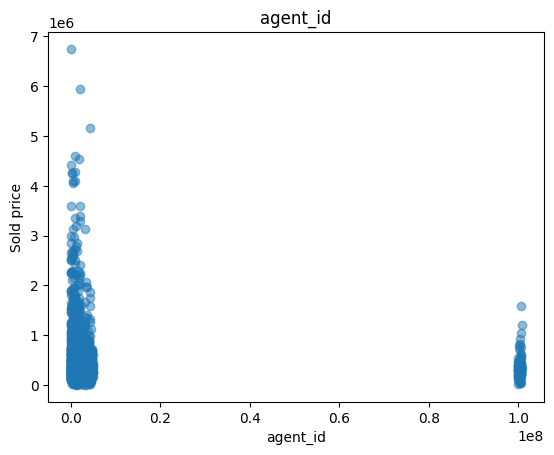

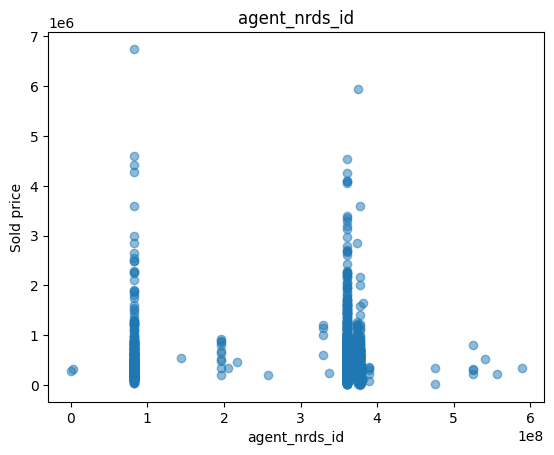

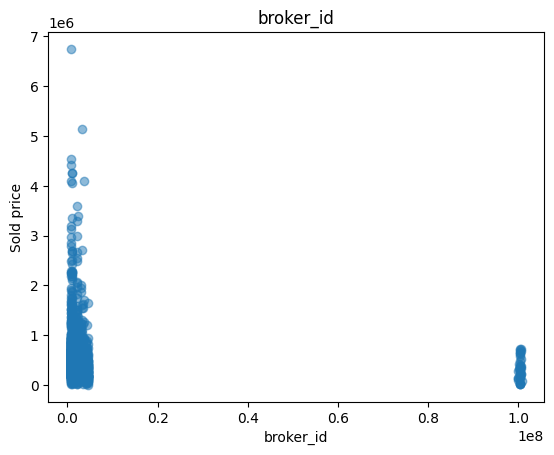

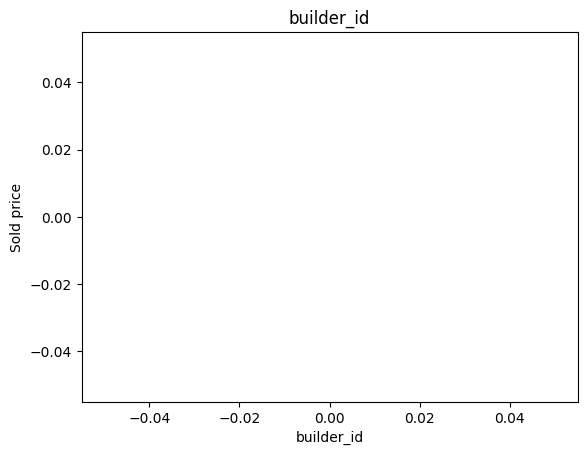

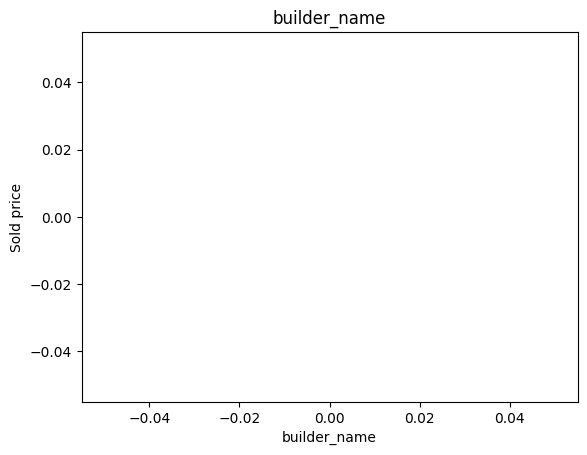

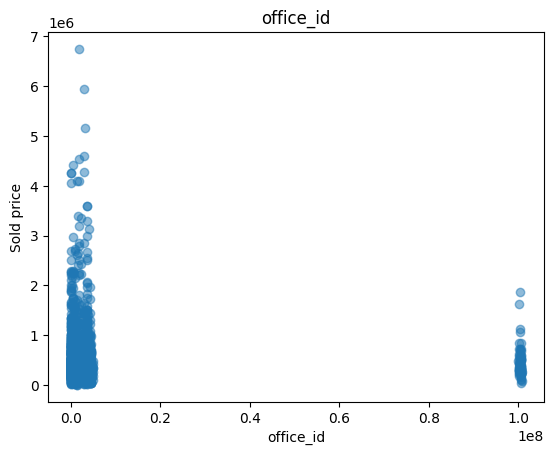

'\n    Insights:\n        Some graphs have little to no data, such as builder_id, and these can be eliminated.\n        There seems to be a relationship between house amenities, such as beds, baths, and \n        sqft, and tax; as these increase, so does the selling price. I will try to keep these attributes.\n\n    Bias:\n        I have my own views on how a house should be evaluated based off of certain features like\n        beds and bathrooms, so I may eliminate other possibly important features that I evaluate as\n        nonessential.\n'

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('listings.csv')

df.columns = ['property_url','property_id', 'listing_id','permalink', 'mls',
             'mls_id', 'status','mls_status','text','style','formatted_address',
             'full_street_line','street','unit','city','state','zip_code','beds',
             'full_baths','half_baths','sqft','year_built','days_on_mls','list_price',
             'list_price_min','list_price_max','list_date','pending_data','sold_price',
              'last_sold_date','last_sold_price','assessed_value','estimated_value',
              'tax','tax_history','new_construction','lot_sqft','price_per_sqft',
              'latitude','longitude','neighborhoods','county','fips_code','stories',
              'hoa_fee','parking_garage','agent_id','agent_name','agent_email',
              'agent_phones','agent_mls_set','agent_nrds_id','broker_id','broker_name',
              'builder_id','builder_name','office_id','office_mls_set','office_name',
              'office_email', 'office_phones','nearby_schools','primary_photo','alt_photos']

# Create scatter plot showing the relationship between the sold price and each of the features
# in the data set.
for i in df.columns[1:]:
    X = df[i]
    price = df["sold_price"]
    if pd.api.types.is_numeric_dtype(X):
        plt.scatter(X,price,alpha=0.5)
        plt.xlabel(i)
        plt.ylabel("Sold price")
        plt.title(i)
        plt.show()

"""
    Insights:
        Some graphs have little to no data, such as builder_id, and these can be eliminated.
        There seems to be a relationship between house amenities, such as beds, baths, and 
        sqft, and tax; as these increase, so does the selling price. I will try to keep these attributes.

    Bias:
        I have my own views on how a house should be evaluated based off of certain features like
        beds and bathrooms, so I may eliminate other possibly important features that I evaluate as
        nonessential.
"""

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [13]:

""" Why:
        I am dropping these columns because they contain nonessential/redundant features.
        For instance, it is redundant to include the city and property_url as they are
        either accounted for or do not effect selling price whatsoever. 
        
        I have kept beds, full_baths, half_baths, sqft, year_built, tax, sold_price, hoa_fee, stories, garage
        because these are viewed as crucial features when determining the value of a house.

    Bias:
        By dropping so many columns, I may be removing data that can effect selling price. Moreover,
        by removing all columns with NaN values, I could be getting rid of more valid data. Also, the features
        I chose can be personally subjective, as these are the main factors I and my family have evaluated
        in our own recent purchasing of a house.
"""
# Keep beds, tax, full_baths, half_baths, sqft, year_built, sold_price, hoa_fee, stories, garage
df = df.drop(columns=['property_url','property_id', 'listing_id','permalink', 'mls',
             'mls_id', 'status','mls_status','text','style','formatted_address',
             'full_street_line','street','unit','city','state','zip_code','days_on_mls','list_price',
             'list_price_min','list_price_max','list_date','pending_data',
              'last_sold_date','last_sold_price','assessed_value','estimated_value','tax_history','new_construction','lot_sqft','price_per_sqft',
              'latitude','longitude','neighborhoods','county','fips_code','agent_id','agent_name','agent_email',
              'agent_phones','agent_mls_set','agent_nrds_id','broker_id','broker_name',
              'builder_id','builder_name','office_id','office_mls_set','office_name',
              'office_email','office_phones','nearby_schools','primary_photo','alt_photos'])

df.dropna()




,beds,full_baths,half_baths,sqft,year_built,sold_price,tax,stories,hoa_fee,parking_garage
218,4.0,2.0,1.0,2250.0,1938.0,705000,8706.0,2.0,0.0,2.0
414,4.0,3.0,1.0,2500.0,2000.0,925000,13543.0,4.0,0.0,1.0
451,5.0,2.0,2.0,4210.0,1901.0,850000,11077.0,3.0,0.0,5.0
481,3.0,2.0,1.0,2400.0,2004.0,617500,10328.0,2.0,200.0,1.0
549,3.0,1.0,1.0,1868.0,1915.0,150000,2960.0,2.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
4113,2.0,2.0,1.0,1691.0,2003.0,789500,16986.0,2.0,1200.0,1.0
4115,4.0,2.0,1.0,2084.0,1916.0,140000,2747.0,2.0,0.0,2.0
4156,3.0,3.0,1.0,3400.0,1899.0,1335000,19133.0,2.0,0.0,2.0
4195,3.0,3.0,1.0,2517.0,2017.0,1510000,40764.0,18.0,2759.0,1.0


# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [ ]:
def infrence(prams):
    results = m.run(prams)
    return results 